# 多层感知机(Multilayer Perceptron)

In [2]:
import torch

### 与门，非门，或门的实现

In [3]:
# 与门
def AND(x1, x2):
    """
    x1, x2为 0 或 1 
    """
    x = torch.tensor([x1, x2, 1], dtype=torch.float32)
    w = torch.tensor([0.5, 0.5, -0.7])
    tmp = sum(x * w)
    if tmp >= 0:
        return 1
    else:
        return 0
    

print(AND(1,1))
print(AND(0,1))
print(AND(0,0))

1
0
0


In [5]:
# 非门
def NAND(x1, x2):
    """
    x1, x2为 0 或 1 
    """
    x = torch.tensor([x1, x2, 1], dtype=torch.float32)
    w = torch.tensor([-0.5, -0.5, 0.7])
    tmp = sum(x * w)
    if tmp >= 0:
        return 1
    else:
        return 0
    
print(NAND(1,1))
print(NAND(0,1))
print(NAND(0,0))

0
1
1


In [6]:
# 或门
def OR(x1, x2):
    """
    x1, x2为 0 或 1 
    """
    x = torch.tensor([x1, x2, 1], dtype=torch.float32)
    w = torch.tensor([0.5, 0.5, -0.2])
    tmp = sum(x * w)
    if tmp >= 0:
        return 1
    else:
        return 0
    
print(OR(1,1))
print(OR(0,1))
print(OR(0,0))

1
1
0


In [7]:
# 与或门
def XOR(x1, x2):
    s1 = OR(x1, x2)
    s2 = NAND(x1, x2)
    return AND(s1, s2)

print(XOR(1,1))
print(XOR(0,1))
print(XOR(0,0))

0
1
0


# 神经网络的搭建

### 1. 网络结构的搭建

In [10]:
import torch
import torch.nn as nn

class Net(nn.Module):
    def __init__(self, input_size=2, hidden_size1=3, hidden_size2=2, output_size=2):
        super(Net, self).__init__()   # 调用父类的方法
        
        # 我们先来搭建神经网络的结构，即这个网络所有的层数 
        self.fc1 = nn.Linear(input_size, hidden_size1)  # 格式：nn.Linear(输入维度，输出维度)
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)  
        self.fc3 = nn.Linear(hidden_size2, output_size)

        # ReLU函数
        

    # 数据传输
    def forward(self, x):
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.fc2(x)
        return x
    
model = Net()


### 2. 训练部分

In [ ]:
# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [ ]:
# Adam 梯度下降讲解
optimizer = torch.optim.Adam(
    model.parameters(),  # 要优化的参数
    lr=0.001,            # 学习率（默认0.001）
    betas=(0.9, 0.999),  # 动量衰减系数 (β1, β2)
    eps=1e-8,            # 防止除零的小常数
    weight_decay=0.0      # L2正则化系数
)

In [11]:
# 原理复习
def explain_adam():
    """
    解释Adam优化器的工作原理
    """
    print("\n" + "="*50)
    print("Adam优化器工作原理")
    print("="*50)
    
    # 模拟一个简单的参数更新
    param = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)
    grad = torch.tensor([0.1, 0.2, 0.3])  # 模拟梯度
    
    print(f"初始参数: {param.data}")
    print(f"梯度: {grad}")
    
    # Adam的两个动量
    m = torch.zeros_like(param)  # 一阶动量（梯度的指数移动平均）
    v = torch.zeros_like(param)  # 二阶动量（梯度平方的指数移动平均）
    
    beta1, beta2 = 0.9, 0.999
    lr = 0.001
    t = 1  # 时间步
    
    print(f"\n第{t}步更新:")
    print(f"  beta1={beta1}, beta2={beta2}, lr={lr}")
    
    # 更新动量
    m = beta1 * m + (1 - beta1) * grad
    v = beta2 * v + (1 - beta2) * grad**2
    
    # 偏差修正
    m_hat = m / (1 - beta1**t)
    v_hat = v / (1 - beta2**t)
    
    print(f"  一阶动量 m: {m}")
    print(f"  二阶动量 v: {v}")
    print(f"  修正后 m_hat: {m_hat}")
    print(f"  修正后 v_hat: {v_hat}")
    
    # 参数更新
    param_update = -lr * m_hat / (torch.sqrt(v_hat) + 1e-8)
    print(f"  参数更新量: {param_update}")
    
    new_param = param + param_update
    print(f"  更新后参数: {new_param.data}")

explain_adam()


Adam优化器工作原理
初始参数: tensor([1., 2., 3.])
梯度: tensor([0.1000, 0.2000, 0.3000])

第1步更新:
  beta1=0.9, beta2=0.999, lr=0.001
  一阶动量 m: tensor([0.0100, 0.0200, 0.0300])
  二阶动量 v: tensor([1.0000e-05, 4.0000e-05, 9.0000e-05])
  修正后 m_hat: tensor([0.1000, 0.2000, 0.3000])
  修正后 v_hat: tensor([0.0100, 0.0400, 0.0900])
  参数更新量: tensor([-0.0010, -0.0010, -0.0010])
  更新后参数: tensor([0.9990, 1.9990, 2.9990])


# 实战：手写数字识别

### 1. 数据处理(不需要了解)

tensor([5, 0, 4,  ..., 4, 5, 6])


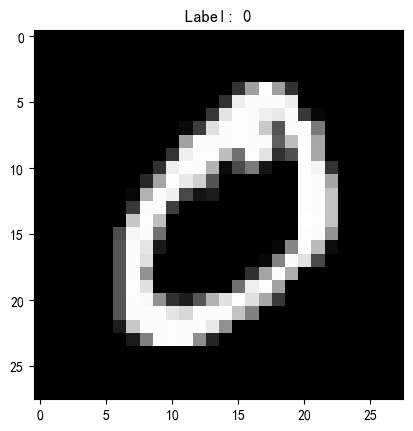

训练集大小: 60000
测试集大小: 10000
批次大小: 64
训练批次数: 938


In [8]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
import numpy as np
from matplotlib import rcParams
rcParams['font.family'] = 'SimHei'

# 设置随机种子
torch.manual_seed(0)
np.random.seed(0)

# 数据预处理
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# 加载MNIST数据集
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

all_images = torch.cat([train_dataset.data.unsqueeze(1).float(), 
                        test_dataset.data.unsqueeze(1).float()], dim=0)  # [70000, 1, 28, 28]
all_images = all_images / 255.0  # 归一化

all_labels = torch.cat([train_dataset.targets, test_dataset.targets], dim=0)  # [70000]

# print(all_images[0])
print(all_labels)

# 可视化第一张图
n = 1
plt.figure()
plt.imshow(all_images[n].squeeze(), cmap='gray')
plt.title(f"Label: {all_labels[n].item()}")
plt.show()

# 创建数据加载器（使用批次）
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"训练集大小: {len(train_dataset)}")
print(f"测试集大小: {len(test_dataset)}")
print(f"批次大小: {batch_size}")
print(f"训练批次数: {len(train_loader)}")


### 2. 神经网络搭建

In [9]:
class MNISTClassifier(nn.Module):
    
    def __init__(self):
        super(MNISTClassifier, self).__init__()
        
        # 将28x28图像展平为784维向量
        self.flatten = nn.Flatten()
        
        # 全连接层
        self.fc1 = nn.Linear(28*28, 128)  # 输入层到隐藏层
        self.fc2 = nn.Linear(128, 64)     # 隐藏层到隐藏层
        self.fc3 = nn.Linear(64, 10)      # 隐藏层到输出层（10个数字）
        
        # 激活函数和dropout
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.flatten(x)                # [batch_size, 784]
        x = self.relu(self.fc1(x))         # [batch_size, 128]
        x = self.relu(self.fc2(x))         # [batch_size, 64]
        x = self.fc3(x)                    # [batch_size, 10] (logits)
        return x

model = MNISTClassifier()
print(model)

MNISTClassifier(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
)


### 3. 确认设备

In [10]:
# 检查是否有GPU可用
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")
model = model.to(device)

使用设备: cuda


d:\Anaconda\envs\pytorch\lib\site-packages\torch\cuda\__init__.py:209: UserWarning: 
NVIDIA GeForce RTX 5060 Laptop GPU with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_50 sm_60 sm_61 sm_70 sm_75 sm_80 sm_86 sm_37 sm_90 compute_37.
If you want to use the NVIDIA GeForce RTX 5060 Laptop GPU GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


### 4. 训练程序

In [11]:
# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 训练函数
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        
        # 前向传播
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, target)
        
        # 反向传播和优化
        loss.backward()
        optimizer.step()
        
        # 统计信息
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += target.size(0)
        correct += predicted.eq(target).sum().item()
        
        # 每100个batch打印一次
        if batch_idx % 100 == 0:
            print(f'Batch: {batch_idx}/{len(train_loader)}, Loss: {loss.item():.4f}')
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc


# 测试函数
def test_epoch(model, test_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            
            outputs = model(data)
            loss = criterion(outputs, target)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += target.size(0)
            correct += predicted.eq(target).sum().item()
    
    epoch_loss = running_loss / len(test_loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc


# 训练模型
num_epochs = 10
train_losses = []
test_losses = []
train_accs = []
test_accs = []

print("开始训练...")
for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    
    # 训练
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # 测试
    test_loss, test_acc = test_epoch(model, test_loader, criterion, device)
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    
    print(f"训练集 - 损失: {train_loss:.4f}, 准确率: {train_acc:.2f}%")
    print(f"测试集 - 损失: {test_loss:.4f}, 准确率: {test_acc:.2f}%")

print("\n训练完成!")

# 保存模型
torch.save(model.state_dict(), 'mnist_classifier.pth')
print("模型已保存为 'mnist_classifier.pth'")

开始训练...

Epoch 1/10
Batch: 0/938, Loss: 2.3280
Batch: 100/938, Loss: 0.3653
Batch: 200/938, Loss: 0.3233
Batch: 300/938, Loss: 0.3620
Batch: 400/938, Loss: 0.1823
Batch: 500/938, Loss: 0.3513
Batch: 600/938, Loss: 0.4002
Batch: 700/938, Loss: 0.3270
Batch: 800/938, Loss: 0.4656
Batch: 900/938, Loss: 0.2233
训练集 - 损失: 0.4012, 准确率: 88.03%
测试集 - 损失: 0.2381, 准确率: 92.76%

Epoch 2/10
Batch: 0/938, Loss: 0.2517
Batch: 100/938, Loss: 0.1134
Batch: 200/938, Loss: 0.1763
Batch: 300/938, Loss: 0.3065
Batch: 400/938, Loss: 0.1241
Batch: 500/938, Loss: 0.2182
Batch: 600/938, Loss: 0.1365
Batch: 700/938, Loss: 0.1966
Batch: 800/938, Loss: 0.2426
Batch: 900/938, Loss: 0.1827
训练集 - 损失: 0.1934, 准确率: 94.14%
测试集 - 损失: 0.1527, 准确率: 95.34%

Epoch 3/10
Batch: 0/938, Loss: 0.1180
Batch: 100/938, Loss: 0.1611
Batch: 200/938, Loss: 0.2026
Batch: 300/938, Loss: 0.1110
Batch: 400/938, Loss: 0.1070
Batch: 500/938, Loss: 0.0638
Batch: 600/938, Loss: 0.0602
Batch: 700/938, Loss: 0.1827
Batch: 800/938, Loss: 0.2423
B

### 5. 测试程序


可视化预测结果...


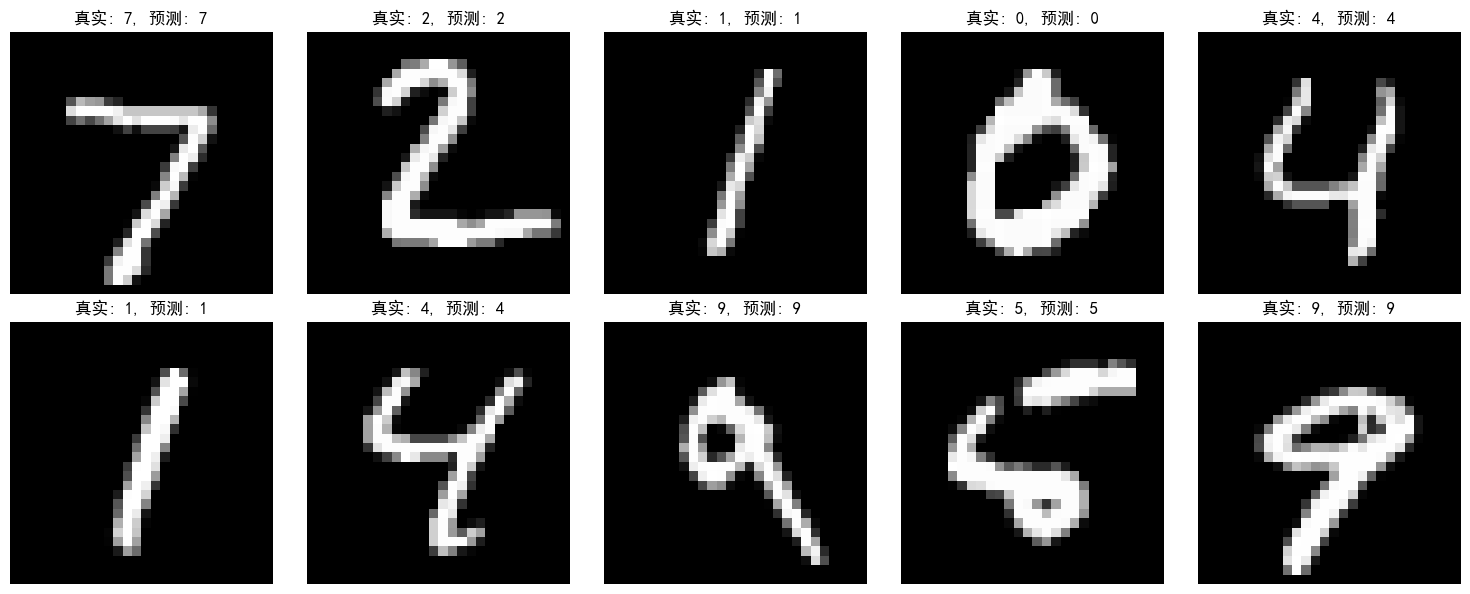


模型在测试集上的最终准确率: 96.36%

=== 交互式预测 ===
输入图像序号 (0-9999) 进行预测，输入 -1 退出


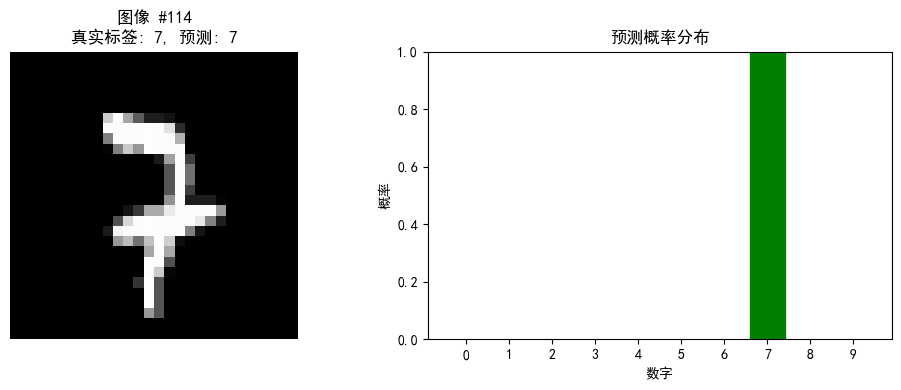

真实标签: 7
预测结果: 7
预测概率: 0.9986
✓ 预测正确!


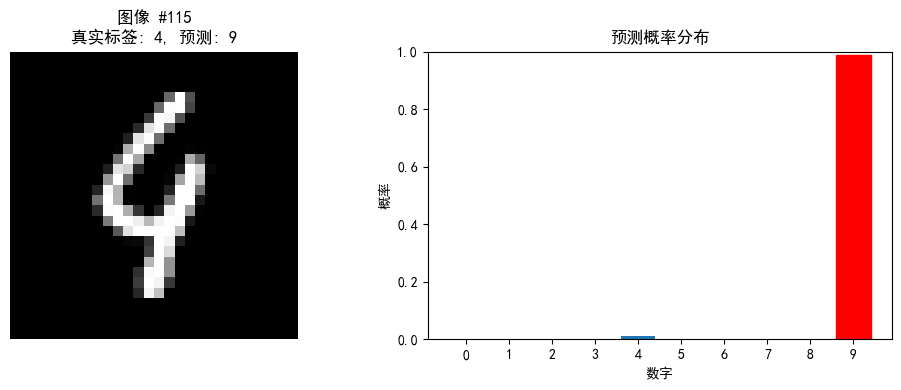

真实标签: 4
预测结果: 9
预测概率: 0.9889
✗ 预测错误!
退出程序


In [12]:
# 预测函数
def predict_image(model, image, device):
    """
    预测单张图片
    Args:
        model: 训练好的模型
        image: 输入图片 (1, 28, 28)
        device: 设备
    Returns:
        predicted_label: 预测的数字
        probabilities: 每个数字的概率
    """
    model.eval()
    with torch.no_grad():
        # 添加批次维度
        if len(image.shape) == 3:
            image = image.unsqueeze(0)  # (1, 1, 28, 28)
        
        image = image.to(device)
        output = model(image)
        
        # 获取预测结果
        probabilities = torch.nn.functional.softmax(output, dim=1)
        predicted_label = torch.argmax(probabilities, dim=1)
        
    return predicted_label.item(), probabilities.squeeze().cpu().numpy()


# 可视化预测结果
def visualize_predictions(model, test_loader, device, num_images=10):
    """
    可视化模型在测试集上的预测结果
    """
    model.eval()
    
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()
    
    with torch.no_grad():
        # 获取一批测试数据
        data, targets = next(iter(test_loader))
        data, targets = data.to(device), targets.to(device)
        
        outputs = model(data)
        _, predictions = outputs.max(1)
        
        for i in range(min(num_images, len(data))):
            ax = axes[i]
            img = data[i].cpu().squeeze()
            
            # 反归一化显示
            img = img * 0.5 + 0.5
            
            ax.imshow(img, cmap='gray')
            ax.set_title(f'真实: {targets[i].item()}, 预测: {predictions[i].item()}')
            ax.axis('off')
            
    
    plt.tight_layout()
    plt.show()


# 使用模型进行预测
print("\n可视化预测结果...")
visualize_predictions(model, test_loader, device)

# 计算整体准确率
def calculate_accuracy(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            outputs = model(data)
            _, predicted = outputs.max(1)
            total += target.size(0)
            correct += predicted.eq(target).sum().item()
    
    accuracy = 100. * correct / total
    return accuracy


# 计算最终准确率
final_accuracy = calculate_accuracy(model, test_loader, device)
print(f"\n模型在测试集上的最终准确率: {final_accuracy:.2f}%")

# 交互式预测示例
print("\n=== 交互式预测 ===")
print("输入图像序号 (0-9999) 进行预测，输入 -1 退出")

while True:
    try:
        idx = int(input("\n请输入测试集图像序号: "))
        
        if idx == -1:
            print("退出程序")
            break
        
        if idx < 0 or idx >= len(test_dataset):
            print(f"序号超出范围，请输入 0-{len(test_dataset)-1} 之间的数字")
            continue
        
        # 获取图像和真实标签
        image, true_label = test_dataset[idx]
        
        # 预测
        predicted_label, probabilities = predict_image(model, image, device)
        
        # 显示结果
        plt.figure(figsize=(10, 4))
        
        # 显示图像
        plt.subplot(1, 2, 1)
        img_display = image.squeeze().cpu().numpy()
        img_display = img_display * 0.5 + 0.5  # 反归一化
        plt.imshow(img_display, cmap='gray')
        plt.title(f'图像 #{idx}\n真实标签: {true_label}, 预测: {predicted_label}')
        plt.axis('off')
        
        # 显示概率分布
        plt.subplot(1, 2, 2)
        bars = plt.bar(range(10), probabilities)
        
        # 高亮显示预测结果
        bars[predicted_label].set_color('red')
        if predicted_label == true_label:
            bars[true_label].set_color('green')
        
        plt.xlabel('数字')
        plt.ylabel('概率')
        plt.title('预测概率分布')
        plt.xticks(range(10))
        plt.ylim([0, 1])
        
        plt.tight_layout()
        plt.show()
        
        print(f"真实标签: {true_label}")
        print(f"预测结果: {predicted_label}")
        print(f"预测概率: {probabilities[predicted_label]:.4f}")
        
        if predicted_label == true_label:
            print("✓ 预测正确!")
        else:
            print("✗ 预测错误!")
            
    except ValueError:
        print("请输入有效的数字")
    except KeyboardInterrupt:
        print("\n程序被用户中断")
        break